# Carga de dataset y librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix,  ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

from modules import *
dataset_path = './data/dataset.csv'

pipeline = PIACEIngestionPipeline(freq_minutes=5)
fe = PIACEFeatureEngineering(config_path="config/moduledb.json")
vis = DatasetVisualizer(config_path="config/moduledb.json")

_RANDOM_SEED = 42

# Random seed para reproducibilidad
np.random.seed(_RANDOM_SEED)


In [2]:
# Cargar el dataset original
df_raw = pipeline.load_data(dataset_path)

print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75017 entries, 0 to 75016
Data columns (total 92 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Time_Temp_A            70422 non-null  object
 1   Temp_A                 70422 non-null  object
 2   Time_Temp_B            71241 non-null  object
 3   Temp_B                 71241 non-null  object
 4   Time_Temp_C            68625 non-null  object
 5   Temp_C                 68625 non-null  object
 6   Time_Hum_A             25582 non-null  object
 7   Hum_A                  25582 non-null  object
 8   Time_Hum_B             24833 non-null  object
 9   Hum_B                  24833 non-null  object
 10  Time_Hum_C             24379 non-null  object
 11  Hum_C                  24379 non-null  object
 12  Time_Pres_A            74805 non-null  object
 13  Pres_A                 74805 non-null  object
 14  Time_Pres_B            74805 non-null  object
 15  Pres_B             

# Preprocesamiento

In [3]:
# 2. Resamplear y alinear todas las 46 señales a la grilla de 5 minutos de Time_CNA
df_resampled = pipeline.process_tag_series(df_raw, reference_time_col='Time_CNA', include_quality_flags=True)

print("Dimensiones tras resampleo:", df_resampled.shape)

display(df_resampled.head())

Dimensiones tras resampleo: (8641, 92)


,Temp_A,Temp_A_Has_Bad,Temp_B,Temp_B_Has_Bad,Temp_C,Temp_C_Has_Bad,Hum_A,Hum_A_Has_Bad,Hum_B,Hum_B_Has_Bad,...,Tag33_ACTIVA,Tag33_ACTIVA_Has_Bad,Tag34_ACTIVA,Tag34_ACTIVA_Has_Bad,Tag35_ACTIVA,Tag35_ACTIVA_Has_Bad,Tag36_ACTIVA,Tag36_ACTIVA_Has_Bad,CNA,CNA_Has_Bad
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-07-01 00:00:00,25.589476,0,25.707078,0,25.746826,0,NaN,0,NaN,0,...,502929.5,0,8915.0,0,272460.500000,0,11767.500000,0,346130.2853,0
2026-07-01 00:05:00,25.400115,0,25.517575,0,25.535419,0,95.420837,0,94.019600,0,...,712402.5,0,8954.5,0,231445.000000,0,11789.666667,0,350361.2279,0
2026-07-01 00:10:00,25.544410,0,25.640861,0,25.697656,0,94.763588,0,93.334053,0,...,708984.5,0,8965.0,0,349121.000000,0,11815.500000,0,349968.6748,0
2026-07-01 00:15:00,25.782943,0,25.974842,0,26.022270,0,NaN,0,NaN,0,...,572265.5,0,8872.5,0,332031.000000,0,11781.500000,0,345046.2714,0
2026-07-01 00:20:00,25.979138,0,26.091581,0,26.186801,0,94.002825,0,92.226969,0,...,665039.0,0,8842.5,0,270507.666667,0,11754.333333,0,346358.9946,0


In [4]:
# 3. Separar variables predictoras (X) y variable objetivo (y: estado Calc Failed)
X_raw = df_resampled.drop(columns=['CNA', 'CNA_Has_Bad'])
# 1 si CNA tuvo error o fue nulo, 0 si fue cálculo normal
y = ((df_resampled['CNA_Has_Bad'] == 1) | (df_resampled['CNA'].isna())).astype(int)

In [5]:
# 4. Extracción de características (Feature Engineering)
# Agrega estado de calidad, discrepancias A/B/C y condiciones de dominio
X = fe.transform(X_raw)
print("Dimensiones finales de X:", X.shape)
print("Distribución de la variable objetivo y (Calc Failed):", y.value_counts().to_dict())

Dimensiones finales de X: (8641, 107)
Distribución de la variable objetivo y (Calc Failed): {0: 8086, 1: 555}


In [6]:
# Comprobar las columnas QualityState generadas (0: Normal, 1: BAD, 2: Vacío)
qs_cols = [c for c in X.columns if c.endswith('_QualityState')]

# Ver distribución en algunas señales clave
for col in ['Temp_A_QualityState', 'Hum_A_QualityState', 'Tag1_QualityState', 'Tag2_QualityState']:
    print(f"{col}: {X[col].value_counts().to_dict()}")

# Visualizar las primeras filas de los estados
X[qs_cols].head()

Temp_A_QualityState: {0: 8639, 1: 1, 2: 1}
Hum_A_QualityState: {0: 7448, 2: 1192, 1: 1}
Tag1_QualityState: {0: 8595, 2: 45, 1: 1}
Tag2_QualityState: {0: 8222, 2: 418, 1: 1}


,Temp_A_QualityState,Temp_B_QualityState,Temp_C_QualityState,Hum_A_QualityState,Hum_B_QualityState,Hum_C_QualityState,Pres_A_QualityState,Pres_B_QualityState,Pres_C_QualityState,Tag1_QualityState,...,Tag27_QualityState,Tag28_QualityState,Tag29_QualityState,Tag30_QualityState,Tag31_ACTIVA_QualityState,Tag32_ACTIVA_QualityState,Tag33_ACTIVA_QualityState,Tag34_ACTIVA_QualityState,Tag35_ACTIVA_QualityState,Tag36_ACTIVA_QualityState
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-07-01 00:00:00,0,0,0,2,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:05:00,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:10:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:15:00,0,0,0,2,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-07-01 00:20:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Tabla comparativa ANTES vs DESPUÉS
display(vis.compare_pre_post(df_raw, X))

# Reporte estadístico preliminar (ejemplo de las primeras 10 señales)
df_no_time = df_raw.filter(regex='^(?!Time_)')
display(vis.summarize_dataset(df_no_time.iloc[:, :10]))
display(vis.summarize_dataset(X.iloc[:, :10]))

,Métrica,Antes (Dataset Crudo),Después (Resampleado a 5 min)
0,Total de Registros (Filas),"75,017 registros dispersos","8,641 intervalos regulares"
1,Total de Columnas,92 columnas (pares Time/Valor),107 señales unificadas
2,Tipo de Intervalo Temporal,"Irregular (por excepción, segundos/minutos)",Regular y continuo (exactamente 5 minutos)
3,Rango de Fechas,Desfasado entre sensores,2026-07-01 00:00:00 a 2026-07-31 00:00:00
4,Alineación entre Sensores,Desalineado (múltiples columnas de tiempo),Sincronizado en un solo Timestamp común
5,Trazabilidad de Errores BAD,"Textos de error mezclados ('Bad', 'Invalid Data')","Separado en Estados de Calidad (0, 1, 2)"


,Columna,Tipo,No_Nulos,Nulos,%_Nulos,Valores_Unicos,Media,Desv_Std,Min,Q1_25%,Mediana,Q3_75%,Max,Atipicos_IQR
0,Temp_A,object,70422,4595,6.13,65914,27.8749,3.5971,22.1293,24.9573,26.8874,30.5425,37.2056,0
1,Temp_B,object,71241,3776,5.03,66120,28.0961,3.7163,22.2260,25.0895,27.0176,30.8862,37.7609,0
2,Temp_C,object,68625,6392,8.52,64358,28.0825,3.6914,22.1992,25.1067,27.0246,30.8322,37.6829,0
3,Hum_A,object,25582,49435,65.90,25463,73.2750,15.4546,33.4239,61.1521,73.0821,86.9348,101.2179,0
4,Hum_B,object,24833,50184,66.90,24730,69.6236,16.3110,27.8817,57.2061,69.1478,83.1762,100.0130,0
5,Hum_C,object,24379,50638,67.50,24281,71.0690,15.4157,31.2518,58.9768,70.8488,84.4534,99.2454,0
6,Pres_A,object,74805,212,0.28,32469,1.0034,0.0022,0.9968,1.0018,1.0036,1.0051,1.0277,83
7,Pres_B,object,74805,212,0.28,41747,1.0020,0.0022,0.9954,1.0004,1.0021,1.0037,1.0245,2
8,Pres_C,object,74805,212,0.28,33139,1.0018,0.0022,0.9952,1.0002,1.0020,1.0036,1.0268,1
9,Tag1,object,21439,53578,71.42,9810,33.6394,0.0833,33.3943,33.5836,33.6195,33.6738,34.0611,1061


,Columna,Tipo,No_Nulos,Nulos,%_Nulos,Valores_Unicos,Media,Desv_Std,Min,Q1_25%,Mediana,Q3_75%,Max,Atipicos_IQR
0,Temp_A,float64,8641,0,0.0,8641,28.0552,3.6598,0.0000,25.0590,27.0762,30.9211,36.9752,1
1,Temp_B,float64,8641,0,0.0,8641,28.2395,3.7499,22.2786,25.1678,27.1886,31.1738,37.5999,0
2,Temp_C,float64,8641,0,0.0,8641,28.3018,3.7510,0.0000,25.2190,27.2862,31.2801,37.4656,1
3,Hum_A,float64,8641,0,0.0,7449,67.6391,31.2081,0.0000,56.4005,77.1966,92.4492,101.2179,1192
4,Hum_B,float64,8641,0,0.0,7409,65.1160,31.2281,0.0000,52.1253,74.3893,90.7857,100.0130,0
5,Hum_C,float64,8641,0,0.0,7516,66.4381,30.0602,0.0000,54.8205,75.3637,90.3209,99.2454,1122
6,Pres_A,float64,8641,0,0.0,8633,1.0034,0.0022,0.9968,1.0018,1.0036,1.0052,1.0084,0
7,Pres_B,float64,8641,0,0.0,8633,1.0020,0.0022,0.9956,1.0004,1.0022,1.0037,1.0069,0
8,Pres_C,float64,8641,0,0.0,8631,1.0018,0.0022,0.9953,1.0002,1.0020,1.0036,1.0070,0
9,Tag1,float64,8641,0,0.0,8465,33.4641,2.4228,0.0000,33.5828,33.6193,33.6733,34.0583,468


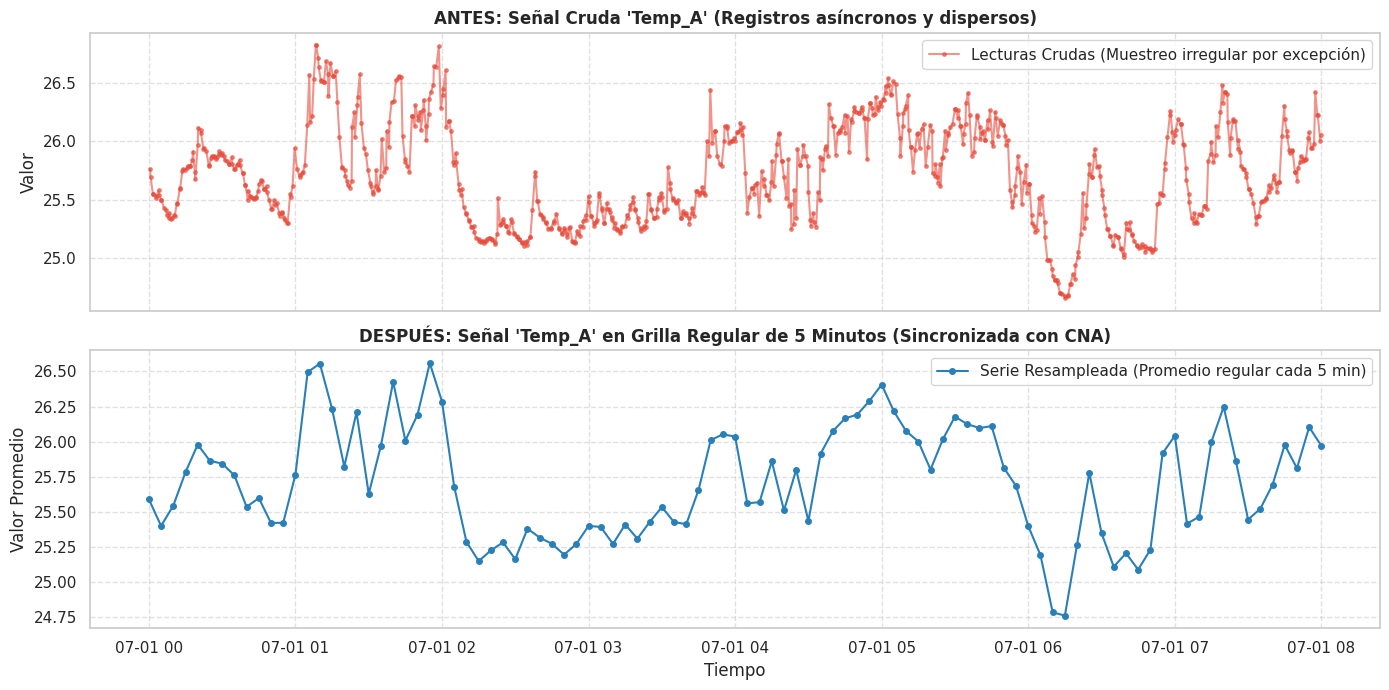

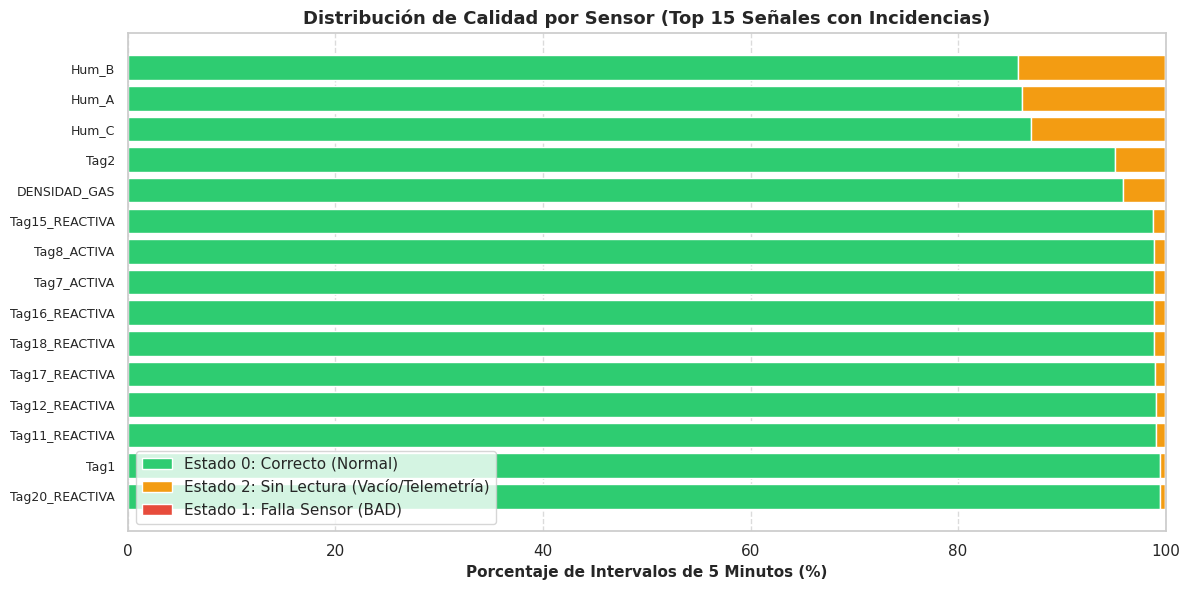

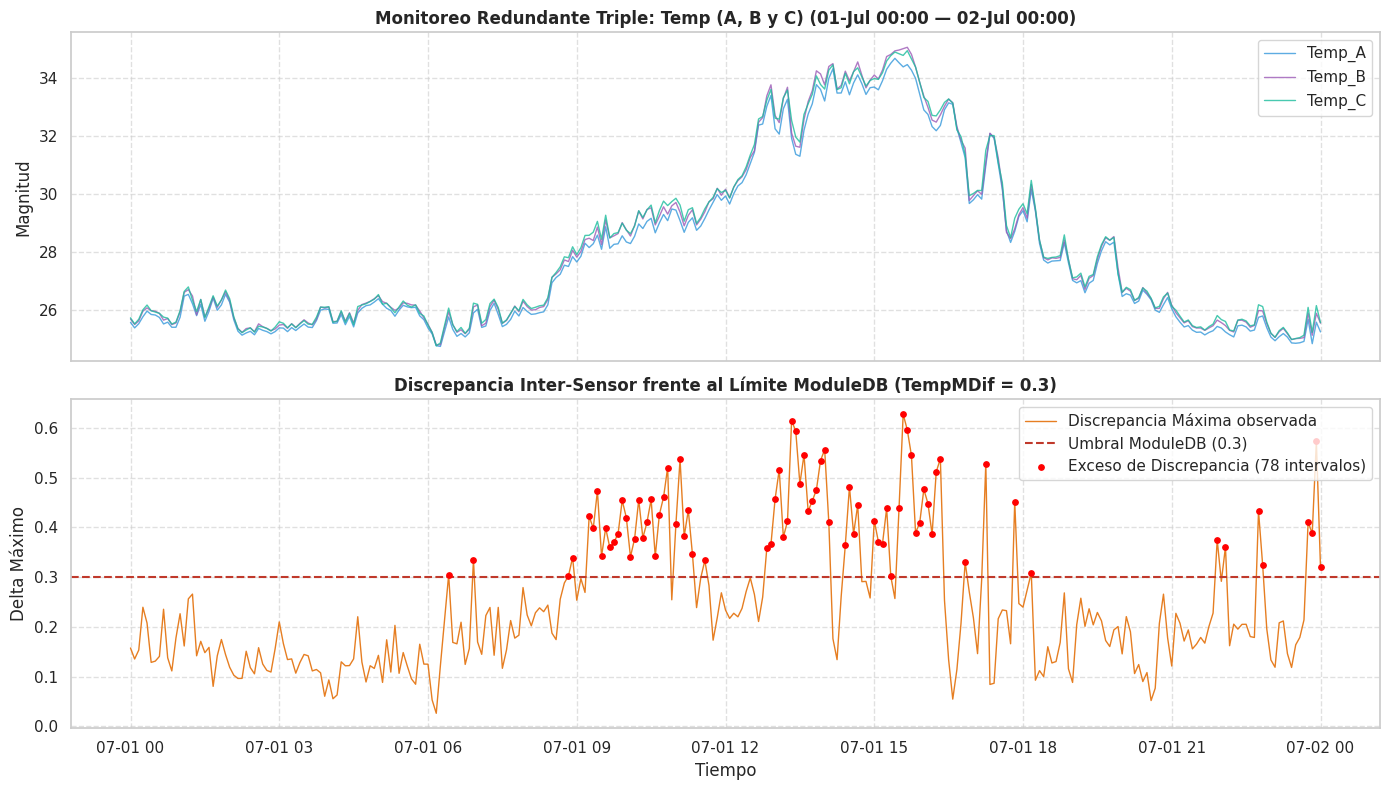

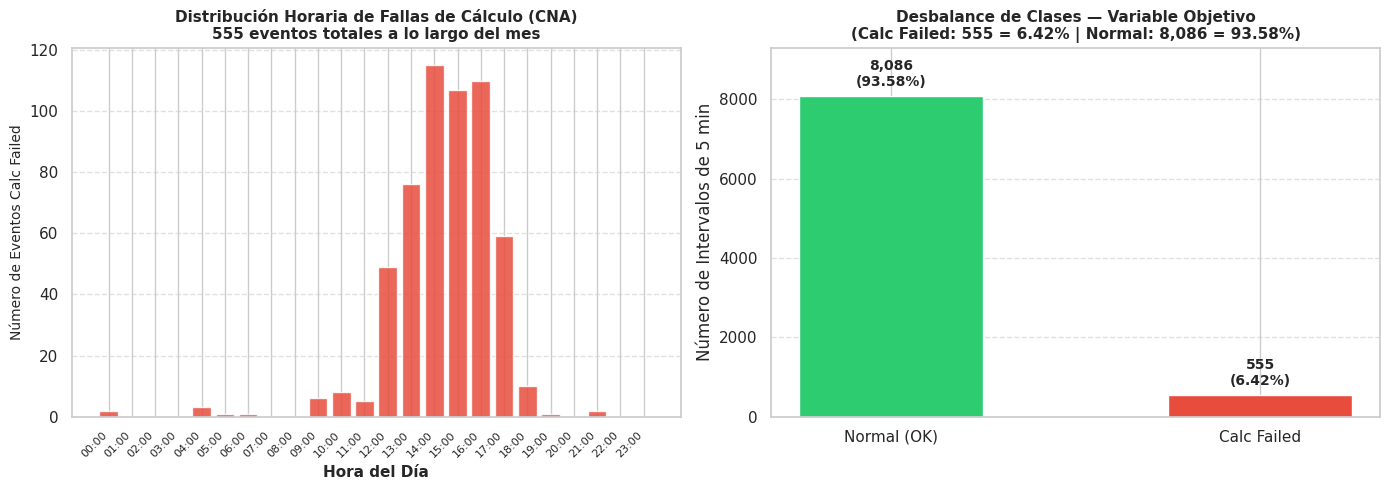

In [8]:
# Gráfica 1: Sincronización Temporal (Antes vs Después)
fig1, _ = vis.plot_resampling_comparison(df_raw, X, tag='Temp_A', sample_hours=8)
plt.show()

# Gráfica 2: Distribución de los 3 Estados de Calidad (0: Normal, 1: BAD, 2: Vacío)
fig2, _ = vis.plot_quality_distribution(X, top_n=15)
plt.show()

# Gráfica 3: Discrepancias Redundantes vs Umbral ModuleDB (Temperatura A, B y C)
fig3, _ = vis.plot_triple_redundancy(df_resampled, variable='Temp',sample_hours=24)
plt.show()

# Gráfica 4: Diagnóstico de la Variable Objetivo (CNA y Calc Failed)
fig4, _ = vis.plot_target_behavior(df_resampled, target_col='CNA')
plt.show()

# Entrenamiento

In [57]:
# Division de los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Numero de positivos y negativos 
neg, pos = y_train.value_counts()
scale_pos = neg / pos

# Definición del modelo
model = xgb.XGBClassifier(
    random_state=_RANDOM_SEED,
    objective='binary:logistic',
    eval_metric='logloss',
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos,
    subsample=1,
    learning_rate=0.05,
    max_depth=10,
    n_estimators=100
) 

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Scale pos weight: {scale_pos}")

Training set size: 6912 samples
Test set size: 1729 samples
Scale pos weight: 14.567567567567568


In [58]:
# Validación Cruzada aplicando solo sobre X_train e y_train

str_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=_RANDOM_SEED)

cv_results = cross_validate(
    estimator=model,
    X=X_train,
    y=y_train,
    cv=str_kfold,
    scoring=['accuracy', 'f1_weighted', 'roc_auc'],
    return_train_score=False
)

print("--- Validación Cruzada sobre X_train (5-Folds) ---")
print(f"Accuracy promedio CV: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"F1-Score promedio CV: {cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")
print(f"ROC-AUC promedio CV:  {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")

--- Validación Cruzada sobre X_train (5-Folds) ---
Accuracy promedio CV: 0.9565 (+/- 0.0056)
F1-Score promedio CV: 0.9591 (+/- 0.0051)
ROC-AUC promedio CV:  0.9732 (+/- 0.0086)


In [61]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# Validación e interpretación

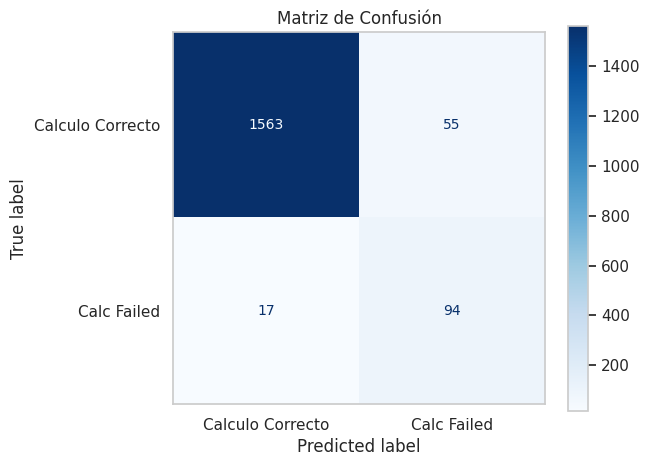


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1618
           1       0.63      0.85      0.72       111

    accuracy                           0.96      1729
   macro avg       0.81      0.91      0.85      1729
weighted avg       0.97      0.96      0.96      1729



In [62]:
# Generar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el desempeño
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Calculo Correcto', 'Calc Failed'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión')
plt.grid(False)
plt.show()

print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

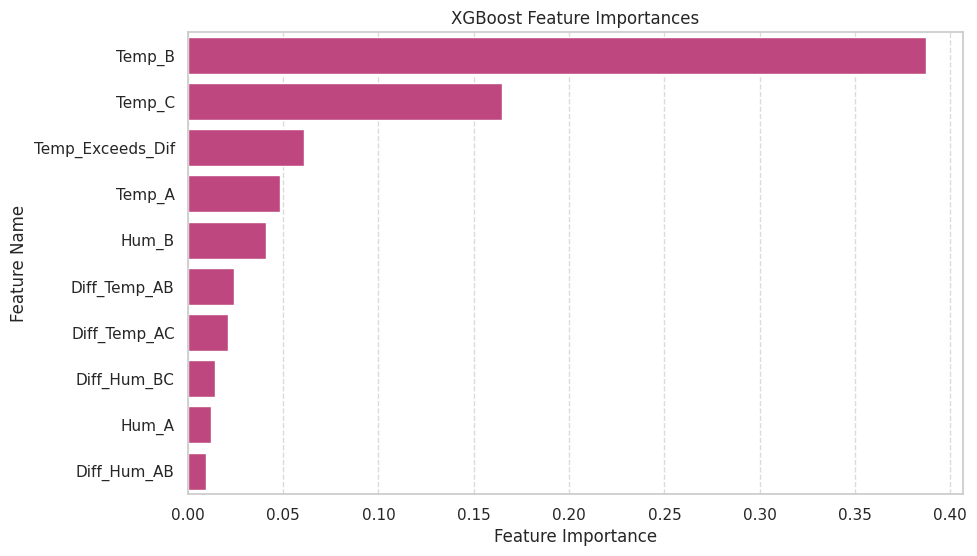

In [63]:
# Feature Importance Plot
# XGBoost has a built-in function to get feature importances
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df[0:10], color="#d3337e")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("XGBoost Feature Importances")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Complementos

## Busqueda de parametros por GridSearchCV

Sirvió como base para encontrar la mejor combinación, la entregada por GridSearchCV no fue la final

In [50]:
# Utiliza GridSearcCV como explorador exhaustivo de hiperparámetros
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [7, 10, 12],
    }

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=str_kfold,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=0.8, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_po...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=5,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [7, 10, 12],
                         'n_estimators': [100, 200, 300]},
             scoring='f1_weighted')

In [64]:
print("--- MEJORES HIPERPARÁMETROS ---")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

--- MEJORES HIPERPARÁMETROS ---
{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}


## Impresión de curva de entrenamiento 

Con los hiperparámetros finales se imprimió la curva de entrenamiento para cuidar el sobreajuste

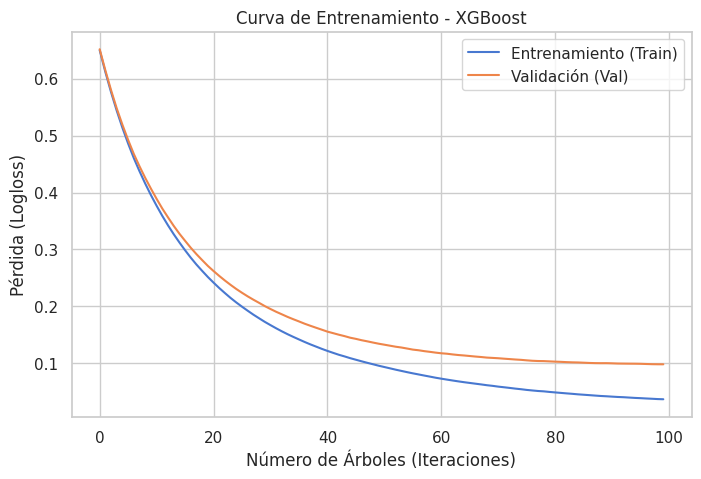


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1618
           1       0.60      0.86      0.70       111

    accuracy                           0.95      1729
   macro avg       0.79      0.91      0.84      1729
weighted avg       0.96      0.95      0.96      1729



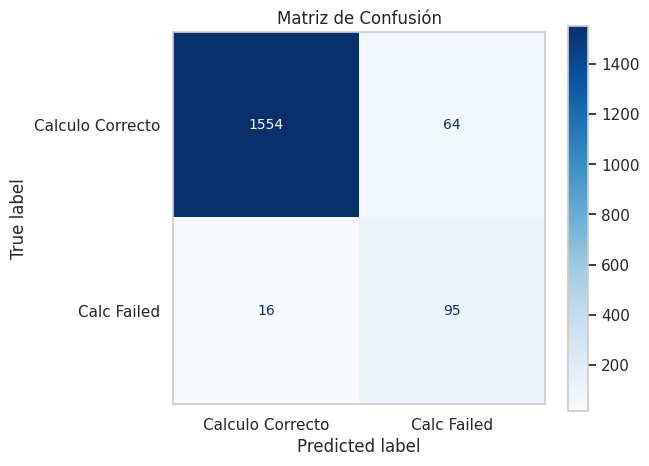

In [65]:
# 1. Definir el modelo y sus parámetros
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

modelo = xgb.XGBClassifier(
    random_state=_RANDOM_SEED,
    objective='binary:logistic',
    eval_metric='logloss',
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos,
    subsample=1,
    learning_rate=0.05,
    max_depth=10,
    n_estimators=100
) 

# 2. Entrenar pasando el eval_set para registrar el progreso
modelo.fit(
    X_tr,
    y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False,
)

# 3. Extraer los resultados de la evaluación
results = modelo.evals_result()

# 4. Graficar la curva de entrenamiento
plt.figure(figsize=(8, 5))
plt.plot(results["validation_0"]["logloss"], label="Entrenamiento (Train)")
plt.plot(results["validation_1"]["logloss"], label="Validación (Val)")
plt.xlabel("Número de Árboles (Iteraciones)")
plt.ylabel("Pérdida (Logloss)")
plt.title("Curva de Entrenamiento - XGBoost")
plt.legend()
plt.show()

y_pred = modelo.predict(X_test)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# Evaluar el desempeño
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Calculo Correcto', 'Calc Failed'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión')
plt.grid(False)
plt.show()